In [1]:
import pymcel as pc
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from celluloid import Camera
from IPython.display import HTML
from IPython.display import display

Bienvenido a PyMCel v0.9.17 ¡al infinito y más allá!


In [8]:
n, t = sp.symbols("n,t")
xp = sp.Function("x'")(t)
yp = sp.Function("y'")(t)
display(xp, yp, n, t)

x'(t)

y'(t)

n

t

In [9]:
x = xp * sp.cos(n*t) - yp * sp.sin(n*t)
y = xp * sp.sin(n*t) + yp * sp.cos(n*t)
display(x, y)

x'(t)*cos(n*t) - y'(t)*sin(n*t)

x'(t)*sin(n*t) + y'(t)*cos(n*t)

In [11]:
xpunto = sp.diff(x,t)
ypunto = sp.diff(y,t)
display(xpunto, ypunto)

-n*x'(t)*sin(n*t) - n*y'(t)*cos(n*t) - sin(n*t)*Derivative(y'(t), t) + cos(n*t)*Derivative(x'(t), t)

n*x'(t)*cos(n*t) - n*y'(t)*sin(n*t) + sin(n*t)*Derivative(x'(t), t) + cos(n*t)*Derivative(y'(t), t)

In [14]:
sp.simplify(sp.expand(xpunto**2 + ypunto**2))

n**2*x'(t)**2 + n**2*y'(t)**2 + 2*n*x'(t)*Derivative(y'(t), t) - 2*n*y'(t)*Derivative(x'(t), t) + Derivative(x'(t), t)**2 + Derivative(y'(t), t)**2

In [18]:
## Ecuaciones del CR3BP

def edm_crtbp(t,Ys,alpha):
    x, y, z, vx, vy, vz = Ys

    #Variables auxiliares
    x1 = -alpha
    x2 = 1-alpha
    r1 = np.sqrt((x-x1)**2 + y**2 + z**2)
    r2 = np.sqrt((x-x2)**2 + y**2 + z**2)

    # Ecuaciones
    dx_dt = vx
    dy_dt = vy
    dz_dt = vz
    dvx_dt = 2*vy+x-(1-alpha)/r1**3*(x-x1)-alpha/r2**3*(x-x2)
    dvy_dt = -2*vx+y-(1-alpha)/r1**3*y-alpha/r2**3*y
    dvz_dt = -(1-alpha)/r1**3*z-alpha/r2**3*z

    return [dx_dt, dy_dt, dz_dt, dvx_dt, dvy_dt, dvz_dt]

In [19]:
edm_crtbp(1, [1, 2, 3, 4, 5, 6], 1)

[4,
 5,
 6,
 np.float64(10.98090991129197),
 np.float64(-6.038180177416061),
 np.float64(-0.05727026612409094)]

In [20]:
from scipy.integrate import solve_ivp

In [38]:
ts = np.linspace(0, 10, 1000)
alpha = 0.3
Ys = [2,0,0,0,0,0]

sol = solve_ivp(edm_crtbp, [ts[0], ts[-1]], Ys, t_eval=ts, args=(alpha,),method='Radau')

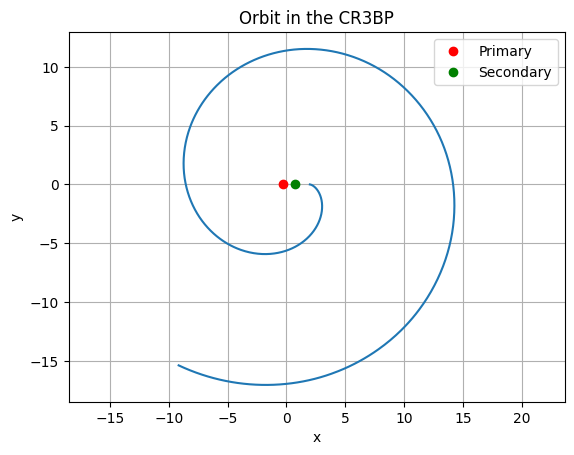

In [39]:
xs = sol.y[0]
ys = sol.y[1]
zs = sol.y[2]
vxs = sol.y[3]
vys = sol.y[4]
vz = sol.y[5]

plt.plot(xs, ys)
plt.plot(-alpha, 0, 'ro', label='Primary')
plt.plot(1-alpha, 0, 'go', label='Secondary')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Orbit in the CR3BP')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()